In [1114]:
import torch

def chebyshev_cgl(N, device="cpu"):
    j = torch.arange(0, N+1, device=device, dtype=torch.float64)
    x = torch.cos(torch.pi * j / N)
    return x

In [1115]:
N = 30
x = chebyshev_cgl(N)

print(x)

tensor([ 1.0000e+00,  9.9452e-01,  9.7815e-01,  9.5106e-01,  9.1355e-01,
         8.6603e-01,  8.0902e-01,  7.4314e-01,  6.6913e-01,  5.8779e-01,
         5.0000e-01,  4.0674e-01,  3.0902e-01,  2.0791e-01,  1.0453e-01,
         2.8328e-16, -1.0453e-01, -2.0791e-01, -3.0902e-01, -4.0674e-01,
        -5.0000e-01, -5.8779e-01, -6.6913e-01, -7.4314e-01, -8.0902e-01,
        -8.6603e-01, -9.1355e-01, -9.5106e-01, -9.7815e-01, -9.9452e-01,
        -1.0000e+00], dtype=torch.float64)


In [1116]:
def chebyshev_diff_matrix(N, device="cpu"):
    x = chebyshev_cgl(N, device)
    
    # coefficients c_i
    c = torch.ones(N+1, device=device, dtype=torch.float64)
    c[0] = 2.0
    c[-1] = 2.0
    
    # Create matrices for vectorized computation
    X = x.unsqueeze(0)            # shape (1, N+1)
    dX = X.T - X                  # x_i - x_j matrix
    
    C = c.unsqueeze(0)
    C_ratio = C.T / C             # c_i / c_j
    
    # sign factor (-1)^{i+j}
    i = torch.arange(N+1, device=device)
    sign = (-1.0) ** (i.unsqueeze(0) + i.unsqueeze(1))
    
    # avoid division by zero (temporary fix)
    dX = dX + torch.eye(N+1, device=device, dtype=torch.float64)
    
    # off-diagonal entries
    D = C_ratio * sign / dX
    
    # fix diagonal entries
    D = D - torch.diag(torch.sum(D, dim=1))
    
    return x, D

In [1117]:
N = 20
x, D = chebyshev_diff_matrix(N)

u = torch.sin(torch.pi * x)
ux_true = torch.pi * torch.cos(torch.pi * x)

ux_pred = D @ u

error = torch.norm(ux_pred - ux_true) / torch.norm(ux_true)
print("Relative error:", error.item())

Relative error: 7.867261838957249e-15


In [1118]:
def chebyshev_basis(x, K):
    # x: (N+1,)
    # K: number of basis functions
    
    x = x.to(torch.float64)
    
    theta = torch.arccos(x)  # (N+1,)
    
    k = torch.arange(0, K, device=x.device, dtype=torch.float64)  # (K,)
    
    # Outer product: theta_i * k
    Phi = torch.cos(theta.unsqueeze(1) * k.unsqueeze(0))  # (N+1, K)
    
    return Phi

In [1119]:
N = 30
K = 20

x = chebyshev_cgl(N)
Phi = chebyshev_basis(x, K)

print("Phi shape:", Phi.shape)

# Check T0(x) = 1
print("T0 correct:", torch.allclose(Phi[:, 0], torch.ones_like(x)))

# Check T1(x) = x
print("T1 error:", torch.norm(Phi[:, 1] - x).item())

Phi shape: torch.Size([31, 20])
T0 correct: True
T1 error: 0.0


In [1120]:
def compute_pde_residual(D, Phi, c, f):
    """
    Computes PDE residual: r_pde = -u_xx - f
    
    Inputs:
        D   : differentiation matrix (N+1, N+1)
        Phi : basis matrix (N+1, K)
        c   : coefficients (K,)
        f   : forcing term evaluated at x (N+1,)
    
    Returns:
        r_pde : (N+1,)
        u     : (N+1,)
    """
    
    # reconstruct solution
    u = Phi @ c
    
    # second derivative
    D2 = D @ D
    u_xx = D2 @ u
    
    # PDE residual
    r_pde = -u_xx - f
    
    return r_pde, u

In [1121]:
N = 30
K = 20

x, D = chebyshev_diff_matrix(N)
Phi = chebyshev_basis(x, K)

# true solution
u_true = torch.sin(torch.pi * x)

# Use the new linalg API
# Note: Phi is (N+1, K), u_true is (N+1, 1)
solution_tuple = torch.linalg.lstsq(Phi, u_true.unsqueeze(1))
c_true = solution_tuple.solution[:K].squeeze() 

# forcing
f = (torch.pi**2) * torch.sin(torch.pi * x)

r_pde, u = compute_pde_residual(D, Phi, c_true, f)

print("Residual norm:", torch.norm(r_pde).item())

Residual norm: 1.5592167820467772e-11


In [1122]:
def compute_bc_residual(u, g_left=0.0, g_right=0.0):
    """
    Dirichlet boundary conditions:
        u(-1) = g_left
        u(1)  = g_right
    """
    return torch.stack([
        u[0] - g_left,
        u[-1] - g_right
    ])

In [1123]:
def compute_full_residual(D, Phi, c, f, bc_weight=1.0):
    """
    Combines PDE + boundary residuals
    """
    r_pde, u = compute_pde_residual(D, Phi, c, f)
    
    r_bc = compute_bc_residual(u)
    
    # weight boundary conditions
    r_bc = bc_weight * r_bc
    
    # stack everything
    r = torch.cat([r_pde, r_bc])
    
    return r, u

In [1124]:
N = 30
K = 20

x, D = chebyshev_diff_matrix(N)
Phi = chebyshev_basis(x, K)

# random coefficients (bad solution)
c = torch.randn(K, dtype=torch.float64)

f = (torch.pi**2) * torch.sin(torch.pi * x)

r, u = compute_full_residual(D, Phi, c, f, bc_weight=10.0)

print("Residual shape:", r.shape)
print("Residual norm:", torch.norm(r).item())

Residual shape: torch.Size([33])
Residual norm: 107733.64052184125


In [1125]:
def build_A(D, bc_weight=1.0):
    """
    Builds A such that:
        r = A u - f
    
    A = [ -D^2
        BC rows ]
    """
    
    Np1 = D.shape[0]
    
    # PDE part
    D2 = D @ D
    A_pde = -D2  # (N+1, N+1)
    
    # Boundary part
    A_bc = torch.zeros(2, Np1, dtype=D.dtype, device=D.device)
    
    A_bc[0, 0] = bc_weight
    A_bc[1, -1] = bc_weight
    
    # Stack
    A = torch.cat([A_pde, A_bc], dim=0)
    
    return A

In [1126]:
N = 30
x, D = chebyshev_diff_matrix(N)

A = build_A(D, bc_weight=10.0)

print("A shape:", A.shape)

A shape: torch.Size([33, 31])


In [1127]:
import torch.nn as nn

class CoeffNet(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 8),
            nn.Tanh(),
            nn.Linear(8, K)
        )
    
    def forward(self):
        x = torch.ones(1, 1, dtype=torch.float64)  # dummy input
        return self.net(x).squeeze()  # (K,)

In [1128]:
def build_B(model):
    """
    Builds B = dc/dtheta
    
    Returns:
        B : (K, P)
    """
    c = model()  # (K,)
    K = c.shape[0]
    
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    
    B = torch.zeros(K, P, dtype=c.dtype)
    
    for k in range(K):
        model.zero_grad()
        
        c[k].backward(retain_graph=True)
        
        grads = []
        for p in params:
            grads.append(p.grad.view(-1))
        
        B[k] = torch.cat(grads)
    
    return B

In [1129]:
K = 20
model = CoeffNet(K).to(torch.float64)

B = build_B(model)

print("B shape:", B.shape)

B shape: torch.Size([20, 268])


In [1130]:
def build_J(model, D, Phi, bc_weight=1.0):
    A = build_A(D, bc_weight)
    B = build_B(model)
    
    J = A @ Phi @ B
    return J

In [1131]:
N = 30
K = 20

# build grid + operators
x, D = chebyshev_diff_matrix(N)
Phi = chebyshev_basis(x, K)

model = CoeffNet(K).to(torch.float64)

J = build_J(model, D, Phi)

print("J shape:", J.shape)

J shape: torch.Size([33, 268])


In [1132]:
def compute_r(model, D, Phi, f, bc_weight=1.0):
    c = model()
    r, u = compute_full_residual(D, Phi, c, f, bc_weight)
    return r, u, c

In [1133]:
## test

f = (torch.pi**2) * torch.sin(torch.pi * x)

r, u, c = compute_r(model, D, Phi, f, bc_weight=10.0)

print("r shape:", r.shape)
print("Residual norm:", torch.norm(r).item())

r shape: torch.Size([33])
Residual norm: 29514.91521941734


In [1134]:
def gauss_newton_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    # compute residual
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    # compute Jacobian
    J = build_J(model, D, Phi, bc_weight)
    
    # normal equations
    JTJ = J.T @ J
    JTr = J.T @ r
    
    # better damping
    mu_scaled = mu * torch.max(torch.diag(JTJ))
    # mu_scaled = mu * torch.trace(JTJ) / JTJ.shape[0]
    
    JTJ = JTJ + mu_scaled * torch.eye(JTJ.shape[0], dtype=JTJ.dtype)
    
    # solve
    delta_theta = -torch.linalg.solve(JTJ, JTr)
    
    return delta_theta, r, JTJ

In [1135]:
def update_model(model, delta_theta, alpha=0.1):
    params = list(model.parameters())
    
    idx = 0
    for p in params:
        numel = p.numel()
        
        delta = delta_theta[idx:idx+numel].view_as(p)
        
        p.data += alpha * delta
        
        idx += numel

In [1136]:
import matplotlib.pyplot as plt

N = 30
K = 20

x, D = chebyshev_diff_matrix(N)
Phi = chebyshev_basis(x, K)

model = CoeffNet(K).to(torch.float64)

f = (torch.pi**2) * torch.sin(torch.pi * x)

loss_history = []

for i in range(1000):
    
    delta_theta, r, JTJ = gauss_newton_step(
        model, D, Phi, f, bc_weight=10.0, mu=1e-3
    )
    
    update_model(model, delta_theta, alpha=0.1)
    
    loss = torch.norm(r).item()
    loss_history.append(loss)
    
    print(f"Iter {i}: Loss = {loss}")

Iter 0: Loss = 27602.581153427414
Iter 1: Loss = 24849.549385310736
Iter 2: Loss = 22370.646963078398
Iter 3: Loss = 20138.675365644274
Iter 4: Loss = 18129.127166872102
Iter 5: Loss = 16319.916368164382
Iter 6: Loss = 14691.138090136521
Iter 7: Loss = 13224.85362109001
Iter 8: Loss = 11904.897474037381
Iter 9: Loss = 10716.703719246565
Iter 10: Loss = 9647.14936494988
Iter 11: Loss = 8684.412946804256
Iter 12: Loss = 7817.846775151069
Iter 13: Loss = 7037.861502895121
Iter 14: Loss = 6335.821838283792
Iter 15: Loss = 5703.952353174915
Iter 16: Loss = 5135.252440479379
Iter 17: Loss = 4623.419562139487
Iter 18: Loss = 4162.780006071736
Iter 19: Loss = 3748.2264398319658
Iter 20: Loss = 3375.1616119998507
Iter 21: Loss = 3039.447610372287
Iter 22: Loss = 2737.360139551765
Iter 23: Loss = 2465.547329762314
Iter 24: Loss = 2220.99263398001
Iter 25: Loss = 2000.9814119411708
Iter 26: Loss = 1803.0708374981716
Iter 27: Loss = 1625.0628003385052
Iter 28: Loss = 1464.9795044712869
Iter 29: Lo

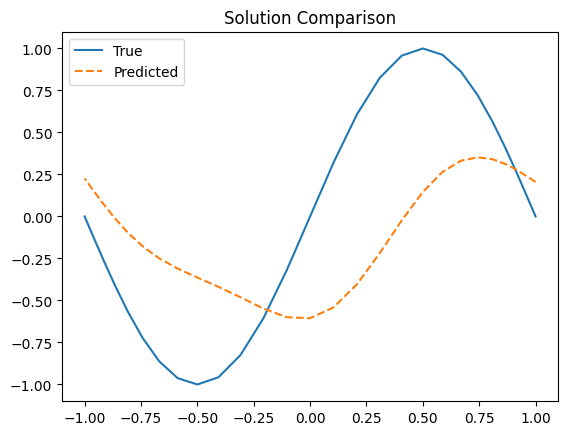

In [1137]:
# true solution
u_true = torch.sin(torch.pi * x)

# predicted
c = model()
u_pred = Phi @ c

plt.figure()
plt.plot(x.numpy(), u_true.numpy(), label="True")
plt.plot(x.numpy(), u_pred.detach().numpy(), '--', label="Predicted")
plt.legend()
plt.title("Solution Comparison")
plt.show()

## Method 1

M=ΦTATAΦ

In [1138]:
def build_M(D, Phi, bc_weight=1.0):
    A = build_A(D, bc_weight)
    
    # A^T A
    ATA = A.T @ A
    
    # M = Φ^T A^T A Φ
    M = Phi.T @ ATA @ Phi
    
    return M

In [1139]:
M = build_M(D, Phi, bc_weight=10.0)
print("M shape:", M.shape)

M shape: torch.Size([20, 20])


b=−BTΦTATr

In [1140]:
def build_rhs(model, D, Phi, r, bc_weight=1.0):
    A = build_A(D, bc_weight)
    B = build_B(model)
    
    rhs = - B.T @ (Phi.T @ (A.T @ r))
    
    return rhs

Hred​=BTMB+μI

In [1141]:
def matvec_reduced(B, M, x, mu):
    
    v1 = B @ x        # (K,)
    v2 = M @ v1       # (K,)
    v3 = B.T @ v2     # (P,)
    
    return v3 + mu * x

In [1142]:
def build_rhs_reduced(B, Phi, A, r):
    
    return - B.T @ (Phi.T @ (A.T @ r))

In [1143]:
def conjugate_gradient(Hx, b, max_iter=50, tol=1e-8):
    """
    Solve Hx = b using Conjugate Gradient
    
    Inputs:
        Hx : function that computes H(x)
        b  : RHS vector (P,)
    
    Returns:
        x  : solution (P,)
    """
    
    x = torch.zeros_like(b)   # initial guess
    
    r = b - Hx(x)             # residual
    p = r.clone()             # search direction
    
    rs_old = torch.dot(r, r)
    
    for i in range(max_iter):
        
        Ap = Hx(p)
        
        alpha = rs_old / (torch.dot(p, Ap) + 1e-12)
        
        x = x + alpha * p
        
        r = r - alpha * Ap
        
        rs_new = torch.dot(r, r)
        
        # convergence check
        if torch.sqrt(rs_new) < tol:
            print(f"CG converged in {i} iterations")
            break
        
        beta = rs_new / (rs_old + 1e-12)
        
        p = r + beta * p
        
        rs_old = rs_new
    
    return x

In [1144]:
def reduced_cg_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    B = build_B(model)
    M = build_M(D, Phi, bc_weight)
    A = build_A(D, bc_weight)
    
    b = build_rhs_reduced(B, Phi, A, r)
    
    def Hx(x):
        return matvec_reduced(B, M, x, mu)
    
    delta_theta = conjugate_gradient(Hx, b, max_iter=50)
    
    return delta_theta, r

In [1145]:
def build_reduced_system(model, D, Phi, M, mu=1e-3):
    B = build_B(model)
    
    H = B.T @ M @ B
    
    # better damping (same as your stable version)
    # mu_scaled = mu * torch.trace(H) / H.shape[0]
    mu_scaled = mu
    
    H = H + mu_scaled * torch.eye(H.shape[0], dtype=H.dtype)
    
    return H, B

In [1146]:
## full reduced gauss-newton step
def reduced_gauss_newton_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    # residual
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    # build M
    M = build_M(D, Phi, bc_weight)
    
    # build system
    H, B = build_reduced_system(model, D, Phi, M, mu)
    
    # RHS
    rhs = build_rhs(model, D, Phi, r, bc_weight)
    
    # solve
    delta_theta = torch.linalg.solve(H, rhs)
    
    return delta_theta, r, H

In [1147]:
## training loop
K = 20
model = CoeffNet(K).to(torch.float64)

f = (torch.pi**2) * torch.sin(torch.pi * x)

loss_history = []

for i in range(300):
    
    delta_theta, r, H = reduced_gauss_newton_step(
        model, D, Phi, f, bc_weight=10.0, mu=1e-3
    )
    
    update_model(model, delta_theta, alpha=0.1)
    
    loss = torch.norm(r).item()
    loss_history.append(loss)
    
    print(f"[Reduced] Iter {i}: Loss = {loss}")

[Reduced] Iter 0: Loss = 35392.38338954575
[Reduced] Iter 1: Loss = 31862.214923906064


[Reduced] Iter 2: Loss = 28680.488665381374
[Reduced] Iter 3: Loss = 25813.71568322002
[Reduced] Iter 4: Loss = 23231.570157647784
[Reduced] Iter 5: Loss = 20906.440623876253
[Reduced] Iter 6: Loss = 18813.23229275375
[Reduced] Iter 7: Loss = 16929.150848347734
[Reduced] Iter 8: Loss = 15233.530989856024
[Reduced] Iter 9: Loss = 13707.655796235766
[Reduced] Iter 10: Loss = 12334.638491538606
[Reduced] Iter 11: Loss = 11099.20048675451
[Reduced] Iter 12: Loss = 9987.586516874891
[Reduced] Iter 13: Loss = 8987.39005171869
[Reduced] Iter 14: Loss = 8087.442893042087
[Reduced] Iter 15: Loss = 7277.691425531561
[Reduced] Iter 16: Loss = 6549.087989918224
[Reduced] Iter 17: Loss = 5893.490341064948
[Reduced] Iter 18: Loss = 5303.575373870684
[Reduced] Iter 19: Loss = 4772.753661048217
[Reduced] Iter 20: Loss = 4295.097303577771
[Reduced] Iter 21: Loss = 3865.276496128376
[Reduced] Iter 22: Loss = 3478.4967563481464
[Reduced] Iter 23: Loss = 3130.4403719741163
[Reduced] Iter 24: Loss = 2817.2

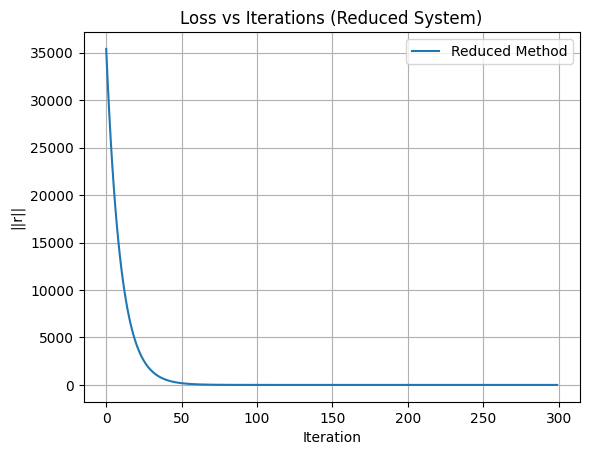

In [1148]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, label="Reduced Method")
plt.title("Loss vs Iterations (Reduced System)")
plt.xlabel("Iteration")
plt.ylabel("||r||")
plt.legend()
plt.grid()
plt.show()

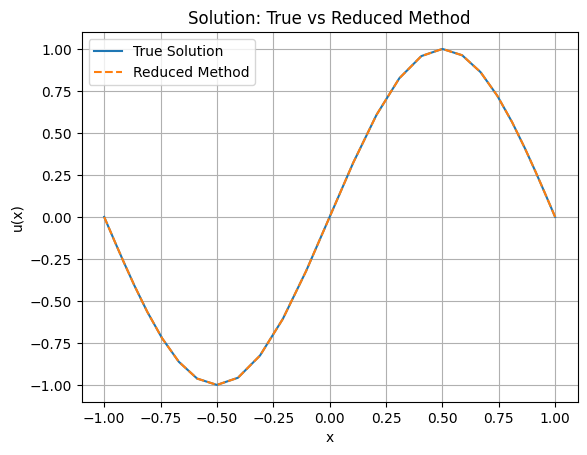

In [1149]:
# true solution
u_true = torch.sin(torch.pi * x)

# predicted
c = model()
u_pred = Phi @ c

plt.figure()
plt.plot(x.detach().cpu().numpy(),
         u_true.detach().cpu().numpy(),
         label="True Solution")

plt.plot(x.detach().cpu().numpy(),
         u_pred.detach().cpu().numpy(),
         '--',
         label="Reduced Method")

plt.legend()
plt.title("Solution: True vs Reduced Method")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid()
plt.show()

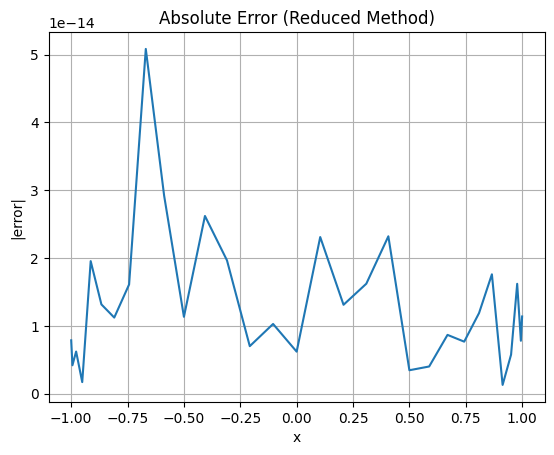

In [1150]:
error = torch.abs(u_pred - u_true)

plt.figure()
plt.plot(x.detach().cpu().numpy(),
         error.detach().cpu().numpy())

plt.title("Absolute Error (Reduced Method)")
plt.xlabel("x")
plt.ylabel("|error|")
plt.grid()
plt.show()

In [1151]:
rel_error = torch.norm(u_pred - u_true) / torch.norm(u_true)
print("Relative Error:", rel_error.item())

sum_abs_error = torch.sum(torch.abs(u_pred - u_true)).item()
print("Sum Absolute Error:", sum_abs_error)

Relative Error: 2.6954144945532856e-14
Sum Absolute Error: 4.118371431286339e-13


(JTJ+μI)x=−JTr

H(x)=JT(Jx)+μx

In [1152]:
def matvec_JTJ(model, D, Phi, x, bc_weight=1.0, mu=1e-3):
    
    # Build components
    A = build_A(D, bc_weight)
    B = build_B(model)
    
    # Step 1: v = Bx
    v1 = B @ x              # (K,)
    
    # Step 2: v = Φ v
    v2 = Phi @ v1           # (N+1,)
    
    # Step 3: v = A v
    v3 = A @ v2             # (N+3,)
    
    # Step 4: v = Aᵀ v
    v4 = A.T @ v3           # (N+1,)
    
    # Step 5: v = Φᵀ v
    v5 = Phi.T @ v4         # (K,)
    
    # Step 6: v = Bᵀ v
    v6 = B.T @ v5           # (P,)
    
    # Damping
    mu_scaled = mu
    
    return v6 + mu_scaled * x

JTJx

In [1153]:
def build_rhs_cg(model, D, Phi, r, bc_weight=1.0):
    A = build_A(D, bc_weight)
    B = build_B(model)
    
    rhs = - B.T @ (Phi.T @ (A.T @ r))
    
    return rhs

In [1154]:
## conjugate gradient solver
def conjugate_gradient(matvec, b, x0=None, max_iter=100, tol=1e-6):
    
    if x0 is None:
        x = torch.zeros_like(b)
    else:
        x = x0.clone()
    
    r = b - matvec(x)
    p = r.clone()
    
    rs_old = torch.dot(r, r)
    
    for i in range(max_iter):
        
        Ap = matvec(p)
        
        alpha = rs_old / torch.dot(p, Ap)
        
        x = x + alpha * p
        r = r - alpha * Ap
        
        rs_new = torch.dot(r, r)
        
        if torch.sqrt(rs_new) < tol:
            print(f"CG converged in {i} iterations")
            break
        
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    
    return x

In [1155]:
def cg_gauss_newton_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    # residual
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    # cache B ONCE
    B = build_B(model)
    A = build_A(D, bc_weight)
    
    # compute mu (your choice)
    mu_scaled = mu * torch.norm(r)
    
    # RHS
    b = - B.T @ (Phi.T @ (A.T @ r))
    
    # operator
    def Hx(x):
        v1 = B @ x
        v2 = Phi @ v1
        v3 = A @ v2
        v4 = A.T @ v3
        v5 = Phi.T @ v4
        v6 = B.T @ v5
        
        return v6 + mu_scaled * x
    
    # solve
    delta_theta = conjugate_gradient(Hx, b, max_iter=50)
    
    return delta_theta, r

In [1156]:
# time measurement
import time

def train_cg(model, D, Phi, f, iterations=300):
    
    loss_history = []
    time_history = []
    
    for i in range(iterations):
        
        t0 = time.perf_counter()
        
        delta_theta, r = cg_gauss_newton_step(
            model, D, Phi, f, bc_weight=10.0, mu=1e-3
        )
        
        update_model(model, delta_theta, alpha=0.1)
        
        t1 = time.perf_counter()
        
        loss = torch.norm(r).item()
        loss_history.append(loss)
        time_history.append(t1 - t0)
        
        print(f"[CG] Iter {i}: Loss={loss}, Time={t1-t0:.4f}s")
    
    return loss_history, time_history

In [1157]:
# memory estimation
def estimate_memory(model, D, Phi):
    
    total = 0
    
    # model params
    for p in model.parameters():
        total += p.numel()
    
    # matrices
    total += D.numel()
    total += Phi.numel()
    
    return total

In [1158]:
model_cg = CoeffNet(K).to(torch.float64)

loss_cg, time_cg = train_cg(model_cg, D, Phi, f, iterations=300)

[CG] Iter 0: Loss=24597.551912348936, Time=0.0047s
[CG] Iter 1: Loss=22133.00613267629, Time=0.0043s
[CG] Iter 2: Loss=19910.5990427154, Time=0.0049s
[CG] Iter 3: Loss=17908.4611317131, Time=0.0045s
[CG] Iter 4: Loss=16106.173912900318, Time=0.0052s
[CG] Iter 5: Loss=14484.730857317105, Time=0.0045s
[CG] Iter 6: Loss=13026.554900413921, Time=0.0043s
[CG] Iter 7: Loss=11715.511221398416, Time=0.0046s
[CG] Iter 8: Loss=10536.886763388773, Time=0.0044s
[CG] Iter 9: Loss=9477.336943088474, Time=0.0038s
[CG] Iter 10: Loss=8524.80599789328, Time=0.0035s
[CG] Iter 11: Loss=7668.432869032485, Time=0.0033s
[CG] Iter 12: Loss=6898.450241426444, Time=0.0033s
[CG] Iter 13: Loss=6206.083523532637, Time=0.0030s
[CG] Iter 14: Loss=5583.455157002129, Time=0.0034s
[CG] Iter 15: Loss=5023.494236219456, Time=0.0034s
[CG] Iter 16: Loss=4519.854239179392, Time=0.0040s
[CG] Iter 17: Loss=4066.838214668768, Time=0.0036s
[CG] Iter 18: Loss=3659.3317793023352, Time=0.0047s
[CG] Iter 19: Loss=3292.7413130837463

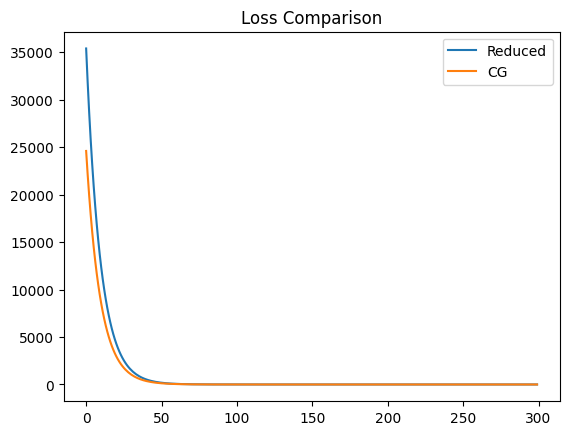

In [1159]:
plt.figure()

plt.plot(loss_history, label="Reduced")
plt.plot(loss_cg, label="CG")

plt.legend()
plt.title("Loss Comparison")
plt.show()

## Time Comparisions

In [1160]:
import time

def train_reduced(model, D, Phi, f, iterations=300):
    
    loss_history = []
    time_history = []
    
    for i in range(iterations):
        
        t0 = time.perf_counter()
        
        delta_theta, r, _ = reduced_gauss_newton_step(
            model, D, Phi, f, bc_weight=10.0, mu=1e-3
        )
        
        update_model(model, delta_theta, alpha=0.1)
        
        t1 = time.perf_counter()
        
        loss = torch.norm(r).item()
        loss_history.append(loss)
        time_history.append(t1 - t0)
        
        print(f"[Reduced] Iter {i}: Loss={loss:.6f}, Time={t1-t0:.4f}s")
    
    return loss_history, time_history

In [1161]:
def train_cg(model, D, Phi, f, iterations=300):
    
    loss_history = []
    time_history = []
    
    for i in range(iterations):
        
        t0 = time.perf_counter()
        
        delta_theta, r = cg_gauss_newton_step(
            model, D, Phi, f, bc_weight=10.0, mu=1e-3
        )
        
        update_model(model, delta_theta, alpha=0.1)
        
        t1 = time.perf_counter()
        
        loss = torch.norm(r).item()
        loss_history.append(loss)
        time_history.append(t1 - t0)
        
        print(f"[CG] Iter {i}: Loss={loss}, Time={t1-t0:.4f}s")
    
    return loss_history, time_history

In [1162]:
model_red = CoeffNet(K).to(torch.float64)
model_cg  = CoeffNet(K).to(torch.float64)

loss_red, time_red = train_reduced(model_red, D, Phi, f)
loss_cg,  time_cg  = train_cg(model_cg,  D, Phi, f)

[Reduced] Iter 0: Loss=24152.342832, Time=0.0042s
[Reduced] Iter 1: Loss=21767.912698, Time=0.0039s
[Reduced] Iter 2: Loss=19613.464878, Time=0.0034s
[Reduced] Iter 3: Loss=17667.745929, Time=0.0034s
[Reduced] Iter 4: Loss=15911.586784, Time=0.0035s
[Reduced] Iter 5: Loss=14327.401295, Time=0.0036s
[Reduced] Iter 6: Loss=12899.079548, Time=0.0030s
[Reduced] Iter 7: Loss=11611.877223, Time=0.0033s
[Reduced] Iter 8: Loss=10452.270315, Time=0.0032s
[Reduced] Iter 9: Loss=9407.864590, Time=0.0031s
[Reduced] Iter 10: Loss=8467.428894, Time=0.0031s
[Reduced] Iter 11: Loss=7620.740452, Time=0.0032s
[Reduced] Iter 12: Loss=6858.554799, Time=0.0030s
[Reduced] Iter 13: Loss=6172.490204, Time=0.0032s
[Reduced] Iter 14: Loss=5554.997758, Time=0.0030s
[Reduced] Iter 15: Loss=4999.239707, Time=0.0030s
[Reduced] Iter 16: Loss=4499.061618, Time=0.0032s
[Reduced] Iter 17: Loss=4048.918823, Time=0.0033s
[Reduced] Iter 18: Loss=3643.809731, Time=0.0031s
[Reduced] Iter 19: Loss=3279.236540, Time=0.0031s
[

In [1163]:
print("Reduced avg time:", sum(time_red)/len(time_red))
print("CG avg time:", sum(time_cg)/len(time_cg))

Reduced avg time: 0.003194670528949549
CG avg time: 0.0028064234678943953


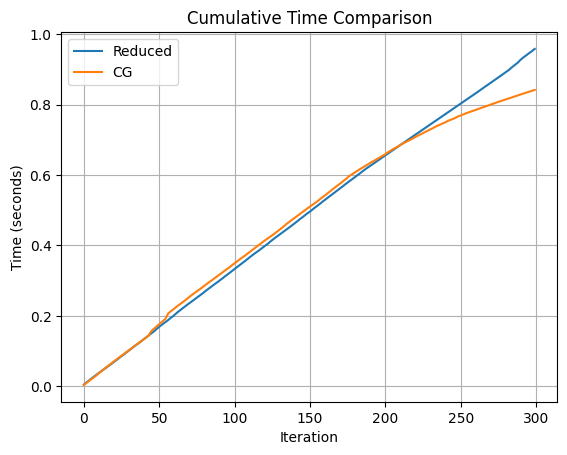

In [1164]:
import numpy as np

plt.figure()
plt.plot(np.cumsum(time_red), label="Reduced")
plt.plot(np.cumsum(time_cg), label="CG")
plt.legend()
plt.title("Cumulative Time Comparison")
plt.xlabel("Iteration")
plt.ylabel("Time (seconds)")
plt.grid()
plt.show()

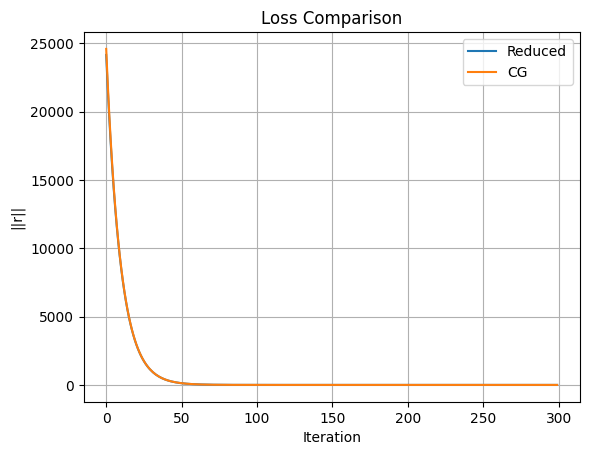

In [1165]:
plt.figure()

plt.plot(loss_red, label="Reduced")
plt.plot(loss_cg, label="CG")

plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Iteration")
plt.ylabel("||r||")
plt.grid()
plt.show()

## Method 3

In [1166]:
def matvec_reduced(B, M, x, mu):
    
    v1 = B @ x
    v2 = M @ v1
    v3 = B.T @ v2
    
    return v3 + mu * x

In [1167]:
rhs = build_rhs(model, D, Phi, r, bc_weight=1.0)

In [1168]:
def reduced_cg_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    B = build_B(model)
    M = build_M(D, Phi, bc_weight)
    
    rhs = build_rhs(model, D, Phi, r, bc_weight)
    
    def Hx(x):
        return matvec_reduced(B, M, x, mu)
    
    delta_theta = conjugate_gradient(Hx, rhs, max_iter=50)
    
    return delta_theta, r

In [1169]:
model_rcg = CoeffNet(K).to(torch.float64)

loss_rcg = []
time_rcg = []

import time

for i in range(300):
    
    t0 = time.perf_counter()
    
    delta_theta, r = reduced_cg_step(
        model_rcg, D, Phi, f, bc_weight=10.0, mu=1e-3
    )
    
    update_model(model_rcg, delta_theta, alpha=0.1)
    
    t1 = time.perf_counter()
    
    loss = torch.norm(r).item()
    
    loss_rcg.append(loss)
    time_rcg.append(t1 - t0)
    
    print(f"[Reduced CG] Iter {i}: Loss = {loss}, Time={t1-t0:.4f}")

[Reduced CG] Iter 0: Loss = 23534.298013751897, Time=0.0044
[Reduced CG] Iter 1: Loss = 21187.69022667304, Time=0.0046
[Reduced CG] Iter 2: Loss = 19073.312928345564, Time=0.0044
[Reduced CG] Iter 3: Loss = 17167.744850380484, Time=0.0044
[Reduced CG] Iter 4: Loss = 15450.535802232012, Time=0.0042
[Reduced CG] Iter 5: Loss = 13903.313374897458, Time=0.0042
[Reduced CG] Iter 6: Loss = 12509.80503751554, Time=0.0042
[Reduced CG] Iter 7: Loss = 11255.17945841895, Time=0.0041
[Reduced CG] Iter 8: Loss = 10125.921103822646, Time=0.0043
[Reduced CG] Iter 9: Loss = 9109.775081115986, Time=0.0039
[Reduced CG] Iter 10: Loss = 8195.601175883387, Time=0.0043
[Reduced CG] Iter 11: Loss = 7373.212665406536, Time=0.0039
[Reduced CG] Iter 12: Loss = 6633.453303551653, Time=0.0040
[Reduced CG] Iter 13: Loss = 5968.0534375080315, Time=0.0041
[Reduced CG] Iter 14: Loss = 5369.526954666525, Time=0.0038
[Reduced CG] Iter 15: Loss = 4831.1423468494895, Time=0.0044
[Reduced CG] Iter 16: Loss = 4346.84633029

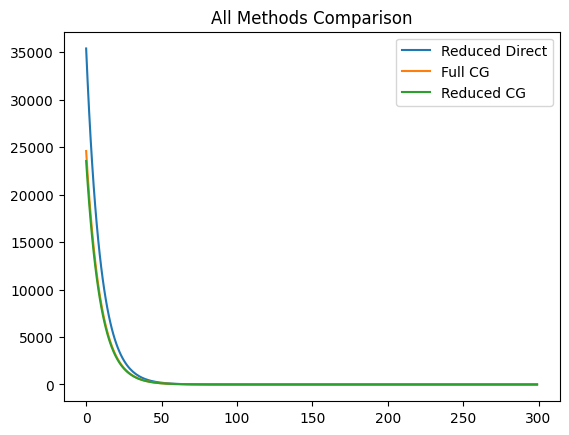

In [1170]:
plt.figure()

plt.plot(loss_history, label="Reduced Direct")
plt.plot(loss_cg, label="Full CG")
plt.plot(loss_rcg, label="Reduced CG")

plt.legend()
plt.title("All Methods Comparison")
plt.show()

In [1171]:
print("Reduced Direct:", sum(time_red)/len(time_red))
print("Full CG:", sum(time_cg)/len(time_cg))
print("Reduced CG:", sum(time_rcg)/len(time_rcg))

Reduced Direct: 0.003194670528949549
Full CG: 0.0028064234678943953
Reduced CG: 0.003773450275572638


## apply HODLR to M

In [1172]:
def split_indices(start, end):
    mid = (start + end) // 2
    return (start, mid), (mid, end)

In [1173]:
def low_rank_approx(block, rank=5):
    
    U, S, Vt = torch.linalg.svd(block, full_matrices=False)
    
    U_r = U[:, :rank]
    S_r = S[:rank]
    V_r = Vt[:rank, :]
    
    return U_r, S_r, V_r

In [1174]:
class HODLRMatrix:
    
    def __init__(self, M, max_level=3, rank=5):
        
        self.M = M
        self.N = M.shape[0]
        self.max_level = max_level
        self.rank = rank
        
        self.blocks = {}
        
        self.build((0, self.N), (0, self.N), level=0)
        
    def build(self, row_range, col_range, level):
        
        r0, r1 = row_range
        c0, c1 = col_range
        
        block = self.M[r0:r1, c0:c1]
        
        # If off-diagonal → low rank
        if r1 <= c0 or c1 <= r0:
            
            U, S, V = low_rank_approx(block, self.rank)
            
            self.blocks[(row_range, col_range)] = ("lowrank", U, S, V)
            return
        
        # If leaf
        if level == self.max_level:
            
            self.blocks[(row_range, col_range)] = ("dense", block)
            return
        
        # Otherwise split
        (rL, rR) = split_indices(r0, r1)
        (cL, cR) = split_indices(c0, c1)
        
        self.build(rL, cL, level+1)
        self.build(rL, cR, level+1)
        self.build(rR, cL, level+1)
        self.build(rR, cR, level+1)
    
    def matvec(self, x):
        
        y = torch.zeros_like(x)
        
        for key, block in self.blocks.items():
            
            (r0, r1), (c0, c1) = key
            
            if block[0] == "dense":
                
                y[r0:r1] += block[1] @ x[c0:c1]
            
            else:
                _, U, S, V = block
                
                # low-rank multiply
                y[r0:r1] += U @ (torch.diag(S) @ (V @ x[c0:c1]))
        
        return y

In [1175]:
def build_HODLR_M(D, Phi, bc_weight=1.0, rank=5):
    
    M = build_M(D, Phi, bc_weight)
    
    H_M = HODLRMatrix(M, max_level=3, rank=rank)
    
    return H_M

In [1176]:
def matvec_reduced_hodlr(B, H_M, x, mu):
    
    v1 = B @ x
    v2 = H_M.matvec(v1)
    v3 = B.T @ v2
    
    return v3 + mu * x

In [1177]:
def reduced_cg_hodlr_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    B = build_B(model)
    H_M = build_HODLR_M(D, Phi, bc_weight)
    
    rhs = build_rhs(model, D, Phi, r, bc_weight)
    
    def Hx(x):
        return matvec_reduced_hodlr(B, H_M, x, mu)
    
    delta_theta = conjugate_gradient(Hx, rhs, max_iter=50)
    
    return delta_theta, r

In [1178]:
model_hodlr = CoeffNet(K).to(torch.float64)

loss_hodlr = []
time_hodlr = []

import time

for i in range(300):
    
    t0 = time.perf_counter()
    
    delta_theta, r = reduced_cg_hodlr_step(
        model_hodlr, D, Phi, f, bc_weight=10.0, mu=1e-3
    )
    
    update_model(model_hodlr, delta_theta, alpha=0.1)
    
    t1 = time.perf_counter()
    
    loss = torch.norm(r).item()
    
    loss_hodlr.append(loss)
    time_hodlr.append(t1 - t0)
    
    print(f"[HODLR] Iter {i}: Loss = {loss}, Time={t1-t0:.4f}")

[HODLR] Iter 0: Loss = 23754.165056159534, Time=0.0196
[HODLR] Iter 1: Loss = 21410.87235366577, Time=0.0203
[HODLR] Iter 2: Loss = 19292.41155239181, Time=0.0196
[HODLR] Iter 3: Loss = 17376.850607185963, Time=0.0180
[HODLR] Iter 4: Loss = 15645.518790725211, Time=0.0195
[HODLR] Iter 5: Loss = 14082.14957206069, Time=0.0201
[HODLR] Iter 6: Loss = 12671.882463118918, Time=0.0186
[HODLR] Iter 7: Loss = 11401.00146873183, Time=0.0197
[HODLR] Iter 8: Loss = 10256.42118681867, Time=0.0201
[HODLR] Iter 9: Loss = 9226.307344396324, Time=0.0196
[HODLR] Iter 10: Loss = 8299.607365456666, Time=0.0180
[HODLR] Iter 11: Loss = 7466.115561351924, Time=0.0188
[HODLR] Iter 12: Loss = 6716.559465890895, Time=0.0182
[HODLR] Iter 13: Loss = 6042.459546344959, Time=0.0189
[HODLR] Iter 14: Loss = 5436.268532070861, Time=0.0179
[HODLR] Iter 15: Loss = 4891.100755054127, Time=0.0181
[HODLR] Iter 16: Loss = 4400.792131388932, Time=0.0180
[HODLR] Iter 17: Loss = 3959.79280294493, Time=0.0178
[HODLR] Iter 18: 

In [1179]:
print("Reduced Direct:", sum(time_red)/len(time_red))
print("Full CG:", sum(time_cg)/len(time_cg))
print("Reduced CG:", sum(time_rcg)/len(time_rcg))
print("HODLR CG:", sum(time_hodlr)/len(time_hodlr))

Reduced Direct: 0.003194670528949549
Full CG: 0.0028064234678943953
Reduced CG: 0.003773450275572638
HODLR CG: 0.015119622756028548


In [1187]:
## FULL HODLR

In [1181]:
def build_J(model, D, Phi, bc_weight=1.0):
    A = build_A(D, bc_weight)
    B = build_B(model)
    return A @ Phi @ B

In [1182]:
def build_H_full(model, D, Phi, bc_weight=1.0, mu=1e-3):
    
    J = build_J(model, D, Phi, bc_weight)
    
    H = J.T @ J
    
    mu_scaled = mu
    
    H = H + mu_scaled * torch.eye(H.shape[0], dtype=H.dtype)
    
    return H

In [1183]:
def build_HODLR_H(model, D, Phi, bc_weight=1.0, mu=1e-3, rank=10):
    
    H = build_H_full(model, D, Phi, bc_weight, mu)
    
    H_hodlr = HODLRMatrix(H, max_level=3, rank=rank)
    
    return H_hodlr

In [1184]:
def matvec_HODLR_full(H_hodlr, x):
    
    return H_hodlr.matvec(x)

In [1185]:
def full_hodlr_cg_step(model, D, Phi, f, bc_weight=1.0, mu=1e-3):
    
    r, u, c = compute_r(model, D, Phi, f, bc_weight)
    
    H_hodlr = build_HODLR_H(model, D, Phi, bc_weight, mu)
    
    rhs = build_rhs(model, D, Phi, r, bc_weight)
    
    def Hx(x):
        return matvec_HODLR_full(H_hodlr, x)
    
    delta_theta = conjugate_gradient(Hx, rhs, max_iter=50)
    
    return delta_theta, r

In [1186]:
model_m5 = CoeffNet(K).to(torch.float64)

loss_m5 = []
time_m5 = []

import time

for i in range(300):
    
    t0 = time.perf_counter()
    
    delta_theta, r = full_hodlr_cg_step(
        model_m5, D, Phi, f, bc_weight=10.0, mu=1e-3
    )
    
    update_model(model_m5, delta_theta, alpha=0.1)
    
    t1 = time.perf_counter()
    
    loss = torch.norm(r).item()
    
    loss_m5.append(loss)
    time_m5.append(t1 - t0)
    
    print(f"[Full HODLR] Iter {i}: Loss = {loss}, Time={t1-t0:.4f}")

[Full HODLR] Iter 0: Loss = 27052.202914786863, Time=0.0225
[Full HODLR] Iter 1: Loss = 24230.63534789263, Time=0.0222
[Full HODLR] Iter 2: Loss = 21752.054383268012, Time=0.0213
[Full HODLR] Iter 3: Loss = 19549.344060403797, Time=0.0224
[Full HODLR] Iter 4: Loss = 17592.630534639975, Time=0.0214
[Full HODLR] Iter 5: Loss = 15849.339790791302, Time=0.0216
[Full HODLR] Iter 6: Loss = 14291.067696909558, Time=0.0213
[Full HODLR] Iter 7: Loss = 12877.01538692762, Time=0.0212
[Full HODLR] Iter 8: Loss = 11601.798847524893, Time=0.0217
[Full HODLR] Iter 9: Loss = 10452.505573979413, Time=0.0211
[Full HODLR] Iter 10: Loss = 9416.667030610923, Time=0.0218
[Full HODLR] Iter 11: Loss = 8483.051847452636, Time=0.0225
[Full HODLR] Iter 12: Loss = 7641.582021978756, Time=0.0238
[Full HODLR] Iter 13: Loss = 6883.200396084759, Time=0.0237
[Full HODLR] Iter 14: Loss = 6199.750756725807, Time=0.0234
[Full HODLR] Iter 15: Loss = 5583.907270751636, Time=0.0238
[Full HODLR] Iter 16: Loss = 5028.96385151